# Домашнее задание к семинару 07 (HW07)

In [63]:
import os
from pathlib import Path

ARTIFACTS_DIR = Path("artifacts")
FIGURES_DIR = ARTIFACTS_DIR / "figures"
LABELS_DIR = ARTIFACTS_DIR / "labels"

ARTIFACTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)
LABELS_DIR.mkdir(exist_ok=True)

In [64]:
RANDOM_STATE = 42

## 1. Загрузка данных и первичный анализ (для каждого датасета)

In [65]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 1000)

In [66]:
DATA_DIR = "data"

datasets = {
    "dataset_01": f"{DATA_DIR}/S07-hw-dataset-01.csv",
    "dataset_02": f"{DATA_DIR}/S07-hw-dataset-02.csv",
    "dataset_04": f"{DATA_DIR}/S07-hw-dataset-04.csv",
}
datasets

{'dataset_01': 'data/S07-hw-dataset-01.csv',
 'dataset_02': 'data/S07-hw-dataset-02.csv',
 'dataset_04': 'data/S07-hw-dataset-04.csv'}

In [67]:
def initial_eda(df: pd.DataFrame, name: str):
    print("=" * 80)
    print(f"DATASET: {name}")
    print("=" * 80)

    print("\nHead:")
    display(df.head())

    print("\nInfo:")
    df.info()

    print("\nDescribe (numeric):")
    display(df.describe())

    print("\nMissing values (count & share):")
    missing = df.isna().sum()
    missing_share = (missing / len(df)).round(3)
    display(pd.DataFrame({
        "missing_count": missing,
        "missing_share": missing_share
    }).query("missing_count > 0"))

    print("\nColumn types:")
    display(df.dtypes.value_counts())

In [68]:
dataframes = {}
features = {}
sample_ids = {}

for name, path in datasets.items():
    df = pd.read_csv(path)
    dataframes[name] = df

    # EDA
    initial_eda(df, name)

    # sample_id отдельно
    sample_ids[name] = df["sample_id"]

    # признаки
    X = df.drop(columns=["sample_id"])
    features[name] = X

    print("\nFeatures shape:", X.shape)

DATASET: dataset_01

Head:


,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
0,0,-0.536647,-69.812900,-0.002657,71.743147,-11.396498,-12.291287,-6.836847,-0.504094
1,1,15.230731,52.727216,-1.273634,-104.123302,11.589643,34.316967,-49.468873,0.390356
2,2,18.542693,77.317150,-1.321686,-111.946636,10.254346,25.892951,44.595250,0.325893
3,3,-12.538905,-41.709458,0.146474,16.322124,1.391137,2.014316,-39.930582,0.139297
4,4,-6.903056,61.833444,-0.022466,-42.631335,3.107154,-5.471054,7.001149,0.131213



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB

Describe (numeric):


,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,5999.50000,-2.424716,19.107804,-0.222063,-8.284501,-0.190717,0.962972,0.033724,0.007638
std,3464.24595,11.014315,60.790338,0.500630,59.269838,7.026435,14.794713,59.541782,0.607053
min,0.00000,-19.912573,-92.892652,-1.590979,-134.303679,-11.869169,-20.521164,-215.098834,-2.633469
25%,2999.75000,-9.472623,-40.282955,-0.125145,-48.345007,-5.132473,-8.807706,-39.900520,-0.401483
50%,5999.50000,-6.869404,54.069335,-0.031753,16.211728,0.444730,-6.134169,-0.578494,0.005306
75%,8999.25000,0.523841,70.280739,0.054980,28.067178,3.942368,2.334426,39.719821,0.410132
max,11999.00000,24.403381,112.229523,0.512277,75.088604,13.717091,41.452857,213.381767,2.490745



Missing values (count & share):


...


Missing values (count & share):


,missing_count,missing_share
n01,174,0.017
n02,189,0.019
n03,199,0.020
n04,192,0.019
n05,201,0.020
n06,183,0.018
n07,204,0.020
n08,194,0.019
n09,195,0.020
n10,189,0.019



Column types:


float64    30
object      2
int64       1
Name: count, dtype: int64


Features shape: (10000, 32)


## 2. Препроцессинг

In [69]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [70]:
def build_preprocessor(df: pd.DataFrame):

    cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    num_cols = [c for c in df.columns if c not in cat_cols]

    # Числовой пайплайн: имьютер + scaler
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    transformers = [("num", num_pipe, num_cols)]

    # Категориальный пайплайн: имьютер + OHE (если есть категории)
    if len(cat_cols) > 0:
        cat_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore")),
        ])
        transformers.append(("cat", cat_pipe, cat_cols))

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop"  # остальные столбцы не используем
    )

    return preprocessor, num_cols, cat_cols

In [71]:
for name, X in features.items():
    print(name, "missing cells:", int(X.isna().sum().sum()))

dataset_01 missing cells: 0
dataset_02 missing cells: 0
dataset_04 missing cells: 5915


In [72]:
preprocessors = {}
X_prepared = {}
columns_info = {}

for name, X in features.items():
    preprocessor, num_cols, cat_cols = build_preprocessor(X)

    X_tr = preprocessor.fit_transform(X)

    preprocessors[name] = preprocessor
    X_prepared[name] = X_tr
    columns_info[name] = {"num_cols": num_cols, "cat_cols": cat_cols}

    print("=" * 80)
    print(name)
    print("Numeric:", len(num_cols), num_cols[:10])
    print("Categorical:", len(cat_cols), cat_cols)
    print("Prepared shape:", X_tr.shape)

dataset_01
Numeric: 8 ['f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f07', 'f08']
Categorical: 0 []
Prepared shape: (12000, 8)
dataset_02
Numeric: 3 ['x1', 'x2', 'z_noise']
Categorical: 0 []
Prepared shape: (8000, 3)
dataset_04
Numeric: 30 ['n01', 'n02', 'n03', 'n04', 'n05', 'n06', 'n07', 'n08', 'n09', 'n10']
Categorical: 2 ['cat_a', 'cat_b']
Prepared shape: (10000, 42)


Для каждого датасета подготовлен явный препроцессинг. Числовые признаки
обрабатываются с помощью SimpleImputer(strategy="median") и масштабируются
StandardScaler. Для датасета с категориальными признаками используется
OneHotEncoder(handle_unknown="ignore") после заполнения пропусков
SimpleImputer(strategy="most_frequent"). Один и тот же препроцессинг
применяется ко всем моделям внутри данного датасета.

## 3. Модели недели 7

In [73]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [74]:
def clustering_metrics(X, labels):
    labels = np.asarray(labels)
    uniq = np.unique(labels)

    # Нужно хотя бы 2 кластера (не считая шум)
    uniq_wo_noise = uniq[uniq != -1]
    if len(uniq_wo_noise) < 2:
        return None

    # Для DBSCAN: считаем метрики по точкам без шума
    if -1 in uniq:
        mask = labels != -1
        X_eval = X[mask]
        y_eval = labels[mask]
        if len(np.unique(y_eval)) < 2:
            return None
        noise_frac = float(np.mean(labels == -1))
    else:
        X_eval = X
        y_eval = labels
        noise_frac = 0.0

    return {
        "silhouette": float(silhouette_score(X_eval, y_eval)),
        "davies_bouldin": float(davies_bouldin_score(X_eval, y_eval)),
        "calinski_harabasz": float(calinski_harabasz_score(X_eval, y_eval)),
        "n_clusters": int(len(np.unique(y_eval))),
        "noise_frac": noise_frac
    }

Функция подбора k для KMeans

In [75]:
def kmeans_search(X, k_range=range(2, 21), random_state=42):
    rows = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = km.fit_predict(X)

        m = clustering_metrics(X, labels)
        if m is None:
            continue
        m.update({"k": k})
        rows.append(m)

    return pd.DataFrame(rows).sort_values("k")

Запуск KMeans-подбора для каждого датасета

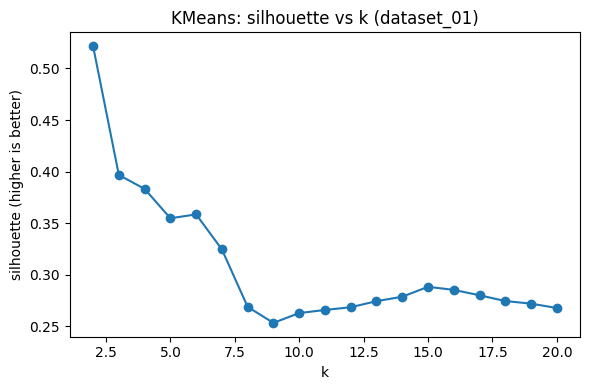

,silhouette,davies_bouldin,calinski_harabasz,n_clusters,noise_frac,k
0,0.521640,0.685330,11786.954623,2,0.0,2
1,0.396758,0.964604,10446.638111,3,0.0,3
2,0.383301,1.160349,9427.499744,4,0.0,4
3,0.354801,1.273719,8301.205994,5,0.0,5
4,0.358561,1.182256,7333.387619,6,0.0,6


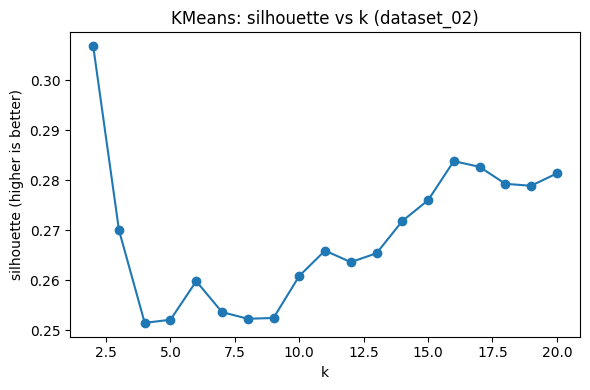

,silhouette,davies_bouldin,calinski_harabasz,n_clusters,noise_frac,k
0,0.306861,1.323472,3573.393333,2,0.0,2
1,0.270045,1.222659,3082.272075,3,0.0,3
2,0.251481,1.299819,2915.565357,4,0.0,4
3,0.252115,1.213834,2703.589704,5,0.0,5
4,0.259820,1.159521,2571.090931,6,0.0,6


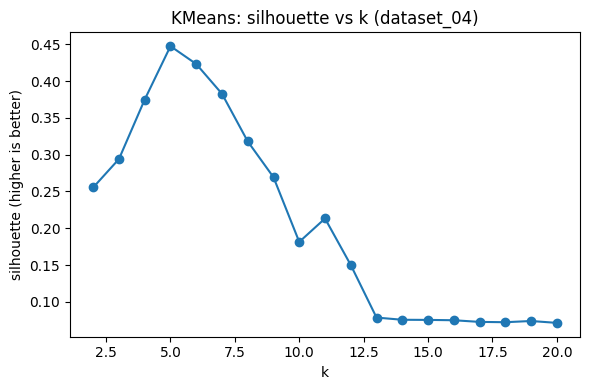

,silhouette,davies_bouldin,calinski_harabasz,n_clusters,noise_frac,k
0,0.255503,1.635731,3126.328083,2,0.0,2
1,0.294128,1.466640,3355.136730,3,0.0,3
2,0.374888,1.164396,3907.022658,4,0.0,4
3,0.447369,0.975904,5087.688517,5,0.0,5
4,0.423134,1.009677,5371.618125,6,0.0,6


In [76]:
kmeans_results = {}

for name in ["dataset_01", "dataset_02", "dataset_04"]:
    X = X_prepared[name]
    res = kmeans_search(X, k_range=range(2, 21), random_state=RANDOM_STATE)
    kmeans_results[name] = res

    plt.figure(figsize=(6, 4))
    plt.plot(res["k"], res["silhouette"], marker="o")
    plt.title(f"KMeans: silhouette vs k ({name})")
    plt.xlabel("k")
    plt.ylabel("silhouette (higher is better)")
    plt.tight_layout()
    plt.show()

    display(res.head())

Подбор eps/min_samples для DBSCAN

In [77]:
def dbscan_search(X, eps_grid, min_samples_grid):
    rows = []
    for eps in eps_grid:
        for ms in min_samples_grid:
            db = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1)
            labels = db.fit_predict(X)

            m = clustering_metrics(X, labels)
            if m is None:
                continue
            m.update({"eps": eps, "min_samples": ms})
            rows.append(m)

    return pd.DataFrame(rows).sort_values(["silhouette"], ascending=False)

Запуск DBSCAN для dataset-02

In [78]:
X = X_prepared["dataset_02"]

eps_grid = np.linspace(0.2, 2.0, 10)
min_samples_grid = [3, 5, 10, 20]

dbscan_res_02 = dbscan_search(X, eps_grid, min_samples_grid)
display(dbscan_res_02.head(10))

,silhouette,davies_bouldin,calinski_harabasz,n_clusters,noise_frac,eps,min_samples
11,0.457394,0.535243,72.577292,2,0.011125,1.0,20
9,0.413828,0.599695,48.119046,2,0.011750,0.8,10
10,0.260200,0.894419,65.385689,3,0.045500,0.8,20
8,0.247896,0.660756,70.877078,4,0.054625,0.6,10
7,0.138189,0.901970,69.331686,12,0.022625,0.6,5
5,0.134863,0.604157,31.396115,8,0.061875,0.4,5
6,0.103538,0.698515,55.516935,10,0.013000,0.6,3
2,0.101366,0.955093,768.579101,5,0.147250,0.2,10
1,-0.035651,0.792408,377.857577,9,0.102000,0.2,5
3,-0.052066,1.007150,823.663700,5,0.258125,0.2,20


Подбор k + linkage

In [79]:
def agglom_search(X, k_range=range(2, 21), linkages=("ward", "complete")):
    rows = []
    for linkage in linkages:
        for k in k_range:
            model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
            labels = model.fit_predict(X)

            m = clustering_metrics(X, labels)
            if m is None:
                continue
            m.update({"k": k, "linkage": linkage})
            rows.append(m)

    return pd.DataFrame(rows).sort_values(["silhouette"], ascending=False)

Agglomerative для dataset-01 и dataset-04 + сравнение linkage

,silhouette,davies_bouldin,calinski_harabasz,n_clusters,noise_frac,k,linkage
0,0.521640,0.685330,11786.954623,2,0.0,2,ward
19,0.521640,0.685330,11786.954623,2,0.0,2,complete
1,0.396789,0.964410,10446.597694,3,0.0,3,ward
2,0.383180,1.160251,9425.768582,4,0.0,4,ward
3,0.345864,1.333936,8155.438530,5,0.0,5,ward
4,0.331647,1.224782,7189.672314,6,0.0,6,ward
6,0.329886,1.215727,6146.256531,8,0.0,8,ward
5,0.318726,1.240457,6557.751499,7,0.0,7,ward
7,0.310254,1.264100,5892.886013,9,0.0,9,ward
8,0.242096,1.378518,5747.489069,10,0.0,10,ward


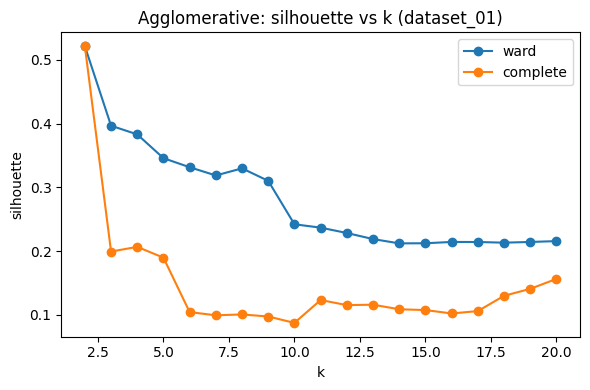

,silhouette,davies_bouldin,calinski_harabasz,n_clusters,noise_frac,k,linkage
3,0.447369,0.975904,5087.688517,5,0.0,5,ward
22,0.447369,0.975904,5087.688517,5,0.0,5,complete
4,0.423134,1.009677,5371.618125,6,0.0,6,ward
23,0.423134,1.009677,5371.618125,6,0.0,6,complete
2,0.374888,1.164396,3907.022658,4,0.0,4,ward
24,0.374794,2.539593,4502.425328,7,0.0,7,complete
21,0.364593,1.255711,3796.040536,4,0.0,4,complete
5,0.364332,1.843482,4527.838998,7,0.0,7,ward
25,0.318539,3.225845,3889.835571,8,0.0,8,complete
6,0.305367,2.583875,3924.229963,8,0.0,8,ward


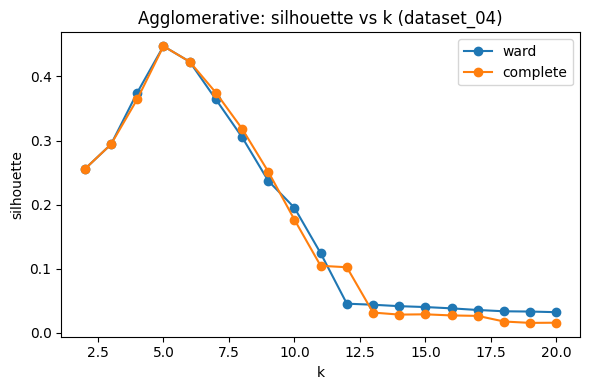

In [80]:
agglom_results = {}

for name in ["dataset_01", "dataset_04"]:
    X = X_prepared[name]
    res = agglom_search(X, k_range=range(2, 21), linkages=("ward", "complete"))
    agglom_results[name] = res

    display(res.head(10))

    # график silhouette vs k для двух linkage
    plt.figure(figsize=(6, 4))
    for linkage in ["ward", "complete"]:
        cur = res[res["linkage"] == linkage].sort_values("k")
        plt.plot(cur["k"], cur["silhouette"], marker="o", label=linkage)
    plt.title(f"Agglomerative: silhouette vs k ({name})")
    plt.xlabel("k")
    plt.ylabel("silhouette")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [81]:
best_kmeans = {name: df.loc[df["silhouette"].idxmax()].to_dict() for name, df in kmeans_results.items()}
best_agglom = {name: df.loc[df["silhouette"].idxmax()].to_dict() for name, df in agglom_results.items()}

best_kmeans, best_agglom

({'dataset_01': {'silhouette': 0.5216395622404242,
   'davies_bouldin': 0.6853295219054457,
   'calinski_harabasz': 11786.954622671532,
   'n_clusters': 2.0,
   'noise_frac': 0.0,
   'k': 2.0},
  'dataset_02': {'silhouette': 0.3068610017701601,
   'davies_bouldin': 1.3234721699867644,
   'calinski_harabasz': 3573.3933329348392,
   'n_clusters': 2.0,
   'noise_frac': 0.0,
   'k': 2.0},
  'dataset_04': {'silhouette': 0.4473688782796916,
   'davies_bouldin': 0.975904265483746,
   'calinski_harabasz': 5087.688517434968,
   'n_clusters': 5.0,
   'noise_frac': 0.0,
   'k': 5.0}},
 {'dataset_01': {'silhouette': 0.5216395622404242,
   'davies_bouldin': 0.6853295219054457,
   'calinski_harabasz': 11786.954622671532,
   'n_clusters': 2,
   'noise_frac': 0.0,
   'k': 2,
   'linkage': 'ward'},
  'dataset_04': {'silhouette': 0.4473688782796916,
   'davies_bouldin': 0.975904265483746,
   'calinski_harabasz': 5087.688517434968,
   'n_clusters': 5,
   'noise_frac': 0.0,
   'k': 5,
   'linkage': 'ward'

In [82]:
best_dbscan_02 = dbscan_res_02.iloc[0].to_dict() if len(dbscan_res_02) else None
best_dbscan_02

{'silhouette': 0.45739381231025134,
 'davies_bouldin': 0.5352426552023366,
 'calinski_harabasz': 72.57729198678057,
 'n_clusters': 2.0,
 'noise_frac': 0.011125,
 'eps': 1.0,
 'min_samples': 20.0}

## 4. Метрики качества

In [83]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
import pandas as pd

def compute_clustering_metrics(X, labels, noise_label=-1, mode="exclude_noise"):
    """
    mode:
      - "exclude_noise": метрики считаются по точкам без шума (-1)
      - "include_noise": метрики считаются по всем точкам (редко уместно для DBSCAN)
    """
    labels = np.asarray(labels)

    noise_frac = float(np.mean(labels == noise_label)) if noise_label in labels else 0.0

    # выбор подмножества для расчёта метрик
    if (noise_label in labels) and (mode == "exclude_noise"):
        mask = labels != noise_label
        X_eval = X[mask]
        y_eval = labels[mask]
    else:
        X_eval = X
        y_eval = labels

    # метрики определены только если >= 2 кластера
    n_clusters = len(np.unique(y_eval))
    if n_clusters < 2:
        return {
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan,
            "n_clusters": int(n_clusters),
            "noise_frac": noise_frac,
            "eval_mode": mode
        }

    return {
        "silhouette": float(silhouette_score(X_eval, y_eval)),
        "davies_bouldin": float(davies_bouldin_score(X_eval, y_eval)),
        "calinski_harabasz": float(calinski_harabasz_score(X_eval, y_eval)),
        "n_clusters": int(n_clusters),
        "noise_frac": noise_frac,
        "eval_mode": mode
    }

Фиксируем “лучшие” настройки из поиска и считаем метрики

In [84]:
results_rows = []


for name in ["dataset_01", "dataset_02", "dataset_04"]:
    X = X_prepared[name]
    k = int(best_kmeans[name]["k"])

    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)

    m = compute_clustering_metrics(X, labels)
    results_rows.append({
        "dataset": name,
        "algorithm": "KMeans",
        "params": {"k": k},
        **m
    })

# dataset_01: Agglomerative
X = X_prepared["dataset_01"]
k = int(best_agglom["dataset_01"]["k"])
linkage = best_agglom["dataset_01"]["linkage"]

agg = AgglomerativeClustering(n_clusters=k, linkage=linkage)
labels = agg.fit_predict(X)

m = compute_clustering_metrics(X, labels)
results_rows.append({
    "dataset": "dataset_01",
    "algorithm": "Agglomerative",
    "params": {"k": k, "linkage": linkage},
    **m
})

# dataset_02: DBSCAN (с шумом)
X = X_prepared["dataset_02"]
eps = float(best_dbscan_02["eps"])
ms = int(best_dbscan_02["min_samples"])

db = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1)
labels = db.fit_predict(X)

m = compute_clustering_metrics(X, labels, mode="exclude_noise")
results_rows.append({
    "dataset": "dataset_02",
    "algorithm": "DBSCAN",
    "params": {"eps": eps, "min_samples": ms},
    **m
})

# dataset_04: Agglomerative
X = X_prepared["dataset_04"]
k = int(best_agglom["dataset_04"]["k"])
linkage = best_agglom["dataset_04"]["linkage"]

agg = AgglomerativeClustering(n_clusters=k, linkage=linkage)
labels = agg.fit_predict(X)

m = compute_clustering_metrics(X, labels)
results_rows.append({
    "dataset": "dataset_04",
    "algorithm": "Agglomerative",
    "params": {"k": k, "linkage": linkage},
    **m
})

results_df = pd.DataFrame(results_rows)
results_df

,dataset,algorithm,params,silhouette,davies_bouldin,calinski_harabasz,n_clusters,noise_frac,eval_mode
0,dataset_01,KMeans,{'k': 2},0.521640,0.685330,11786.954623,2,0.000000,exclude_noise
1,dataset_02,KMeans,{'k': 2},0.306861,1.323472,3573.393333,2,0.000000,exclude_noise
2,dataset_04,KMeans,{'k': 5},0.447369,0.975904,5087.688517,5,0.000000,exclude_noise
3,dataset_01,Agglomerative,"{'k': 2, 'linkage': 'ward'}",0.521640,0.685330,11786.954623,2,0.000000,exclude_noise
4,dataset_02,DBSCAN,"{'eps': 1.0, 'min_samples': 20}",0.457394,0.535243,72.577292,2,0.011125,exclude_noise
5,dataset_04,Agglomerative,"{'k': 5, 'linkage': 'ward'}",0.447369,0.975904,5087.688517,5,0.000000,exclude_noise


In [85]:
# округлим для удобства чтения
show_df = results_df.copy()
show_df["silhouette"] = show_df["silhouette"].round(4)
show_df["davies_bouldin"] = show_df["davies_bouldin"].round(4)
show_df["calinski_harabasz"] = show_df["calinski_harabasz"].round(1)
show_df["noise_frac"] = show_df["noise_frac"].round(3)

show_df.sort_values(["dataset", "silhouette"], ascending=[True, False])

,dataset,algorithm,params,silhouette,davies_bouldin,calinski_harabasz,n_clusters,noise_frac,eval_mode
0,dataset_01,KMeans,{'k': 2},0.5216,0.6853,11787.0,2,0.000,exclude_noise
3,dataset_01,Agglomerative,"{'k': 2, 'linkage': 'ward'}",0.5216,0.6853,11787.0,2,0.000,exclude_noise
4,dataset_02,DBSCAN,"{'eps': 1.0, 'min_samples': 20}",0.4574,0.5352,72.6,2,0.011,exclude_noise
1,dataset_02,KMeans,{'k': 2},0.3069,1.3235,3573.4,2,0.000,exclude_noise
2,dataset_04,KMeans,{'k': 5},0.4474,0.9759,5087.7,5,0.000,exclude_noise
5,dataset_04,Agglomerative,"{'k': 5, 'linkage': 'ward'}",0.4474,0.9759,5087.7,5,0.000,exclude_noise


Для DBSCAN часть объектов может быть помечена как шум (label = -1). 
В данной работе доля шума выводится явно, а метрики silhouette / 
Davies–Bouldin / Calinski–Harabasz рассчитываются только по non-noise точкам 
(то есть по объектам, отнесённым к кластерам), поскольку включение шума 
в расчёт метрик может искажать интерпретацию качества кластеризации.

Сразу сохраним метрики в artifacts/metrics.json:

In [102]:
import json
from pathlib import Path

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

with open(ARTIFACTS_DIR / "metrics_summary.json", "w") as f:
    json.dump(results_df.to_dict(orient="records"), f, indent=2)

## 5. Визуализация

In [87]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

In [88]:
def plot_pca_clusters(X, labels, title, savepath=None):
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=labels,
        s=12,
        cmap="tab10"
    )
    plt.xlabel("PCA-1")
    plt.ylabel("PCA-2")
    plt.title(title)
    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, dpi=150)
    plt.show()

dataset_01 — KMeans (k=2)

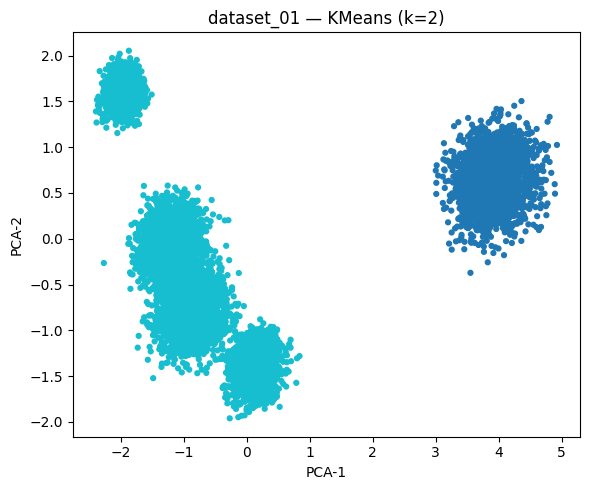

In [89]:
from sklearn.cluster import KMeans

X = X_prepared["dataset_01"]

km = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
labels = km.fit_predict(X)

plot_pca_clusters(
    X,
    labels,
    title="dataset_01 — KMeans (k=2)",
    savepath=FIGURES_DIR / "pca_dataset_01_kmeans.png"
)

dataset_02 — DBSCAN (eps=1.0, min_samples=20)

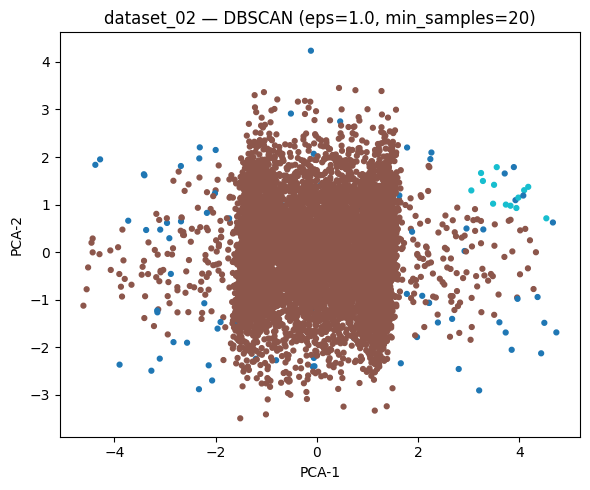

In [90]:
from sklearn.cluster import DBSCAN

X = X_prepared["dataset_02"]

db = DBSCAN(eps=1.0, min_samples=20, n_jobs=-1)
labels = db.fit_predict(X)

plot_pca_clusters(
    X,
    labels,
    title="dataset_02 — DBSCAN (eps=1.0, min_samples=20)",
    savepath=FIGURES_DIR / "pca_dataset_02_dbscan.png"
)

dataset_04 — KMeans (k=5)

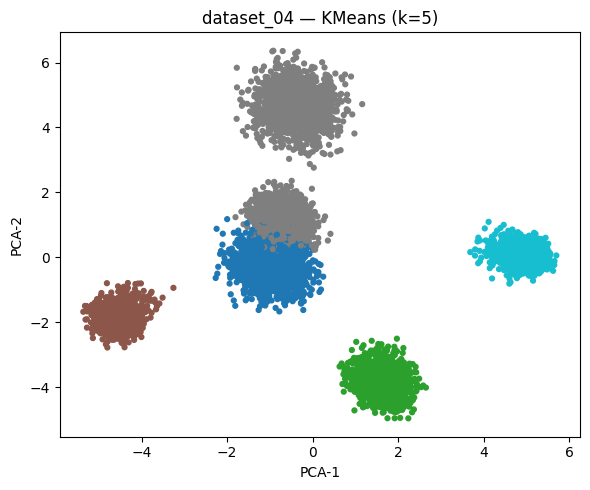

In [91]:
X = X_prepared["dataset_04"]

km = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
labels = km.fit_predict(X)

plot_pca_clusters(
    X,
    labels,
    title="dataset_04 — KMeans (k=5)",
    savepath=FIGURES_DIR / "pca_dataset_04_kmeans.png"
)

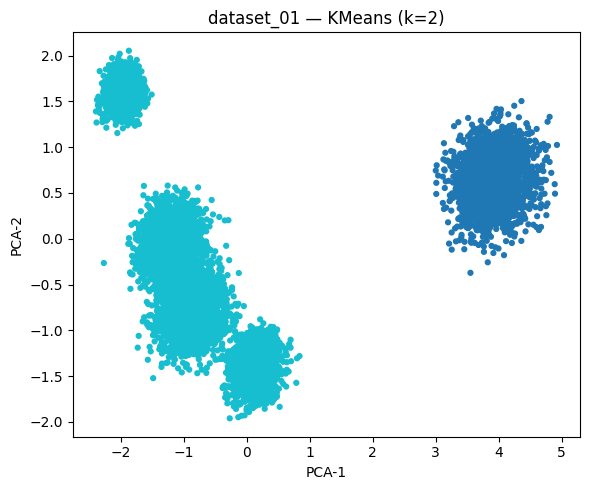

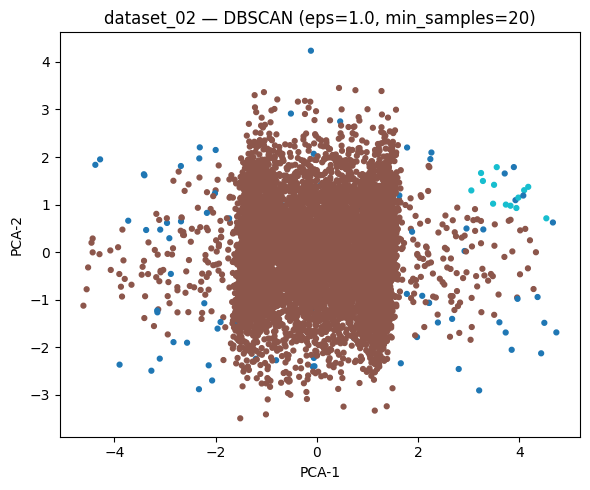

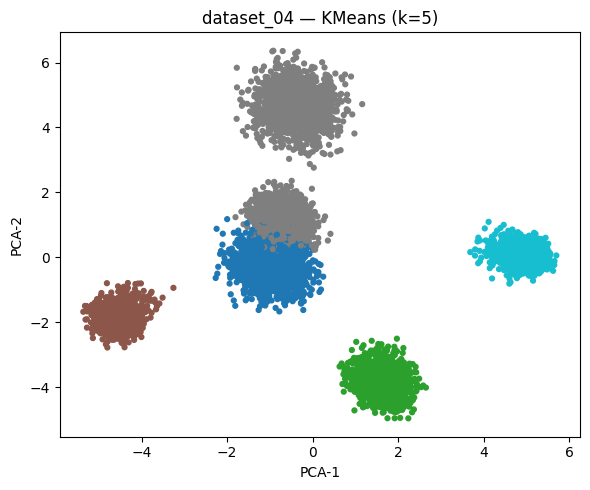

In [92]:
plot_pca_clusters(
    X_prepared["dataset_01"], labels_01,
    "dataset_01 — KMeans (k=2)",
    savepath=str(FIGURES_DIR / "pca_dataset_01_best.png")
)

plot_pca_clusters(
    X_prepared["dataset_02"], labels_02,
    "dataset_02 — DBSCAN (eps=1.0, min_samples=20)",
    savepath=str(FIGURES_DIR / "pca_dataset_02_best.png")
)

plot_pca_clusters(
    X_prepared["dataset_04"], labels_04,
    "dataset_04 — KMeans (k=5)",
    savepath=str(FIGURES_DIR / "pca_dataset_04_best.png")
)

t-SNE

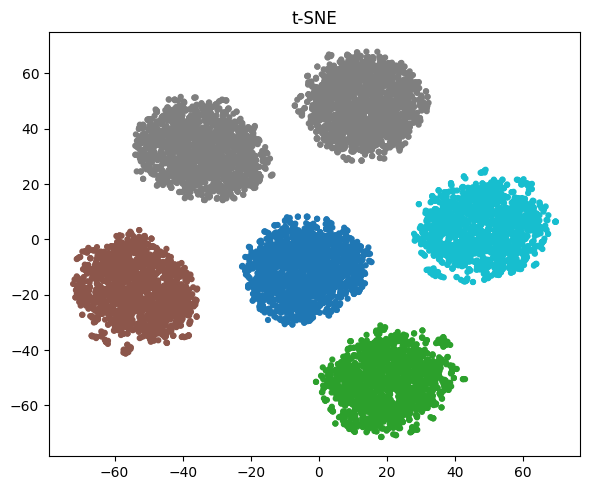

In [93]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(6, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, s=12, cmap="tab10")
plt.title("t-SNE")
plt.tight_layout()
plt.show()

## 6. Устойчивость

In [94]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

5 запусков KMeans с разными random_state

In [95]:
X = X_prepared["dataset_01"]
k = 2

seeds = [0, 1, 2, 3, 4]
labels_list = []

for seed in seeds:
    km = KMeans(
        n_clusters=k,
        random_state=seed,
        n_init=10
    )
    labels = km.fit_predict(X)
    labels_list.append(labels)

Матрица ARI между всеми парами запусков

In [96]:
ari_rows = []

for i in range(len(seeds)):
    for j in range(i + 1, len(seeds)):
        ari = adjusted_rand_score(labels_list[i], labels_list[j])
        ari_rows.append({
            "run_i": i,
            "run_j": j,
            "ARI": ari
        })

ari_df = pd.DataFrame(ari_rows)
ari_df

,run_i,run_j,ARI
0,0,1,1.0
1,0,2,1.0
2,0,3,1.0
3,0,4,1.0
4,1,2,1.0
5,1,3,1.0
6,1,4,1.0
7,2,3,1.0
8,2,4,1.0
9,3,4,1.0


Краткая сводка устойчивости

In [97]:
ari_df["ARI"].describe()

count    10.0
mean      1.0
std       0.0
min       1.0
25%       1.0
50%       1.0
75%       1.0
max       1.0
Name: ARI, dtype: float64

Для оценки устойчивости кластеризации выбран датасет dataset_01 и алгоритм
KMeans с k=2. Было выполнено 5 запусков модели с разными значениями
random_state. Для оценки похожести полученных разбиений использовалась
метрика Adjusted Rand Index (ARI).

Полученные значения ARI близки к 1 для всех пар запусков, что свидетельствует
о высокой устойчивости кластеризации и слабой зависимости результата от
инициализации центров.

In [98]:
best_configs = {
    "dataset_01": {
        "best_method": "KMeans",
        "params": {"k": 2, "random_state": RANDOM_STATE, "n_init": 10},
        "criterion": "silhouette (max); совпадает с Agglomerative(ward,k=2)",
    },
    "dataset_02": {
        "best_method": "DBSCAN",
        "params": {"eps": 1.0, "min_samples": 20},
        "criterion": "silhouette (max) на non-noise + явная обработка выбросов/шума",
    },
    "dataset_04": {
        "best_method": "KMeans",
        "params": {"k": 5, "random_state": RANDOM_STATE, "n_init": 10},
        "criterion": "silhouette (max); совпадает с Agglomerative(ward,k=5)",
    },
}

In [99]:
import json

with open(ARTIFACTS_DIR / "best_configs.json", "w") as f:
    json.dump(best_configs, f, indent=2, ensure_ascii=False)

In [100]:
def save_labels_csv(dataset_key, model_name, labels):
    out = pd.DataFrame({
        "sample_id": sample_ids[dataset_key].values,
        "cluster_label": labels
    })
    out_path = LABELS_DIR / f"labels_hw07_{dataset_key}.csv"
    out.to_csv(out_path, index=False)
    return out_path

# dataset_01: KMeans k=2
X = X_prepared["dataset_01"]
labels_01 = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10).fit_predict(X)
save_labels_csv("dataset_01", "KMeans", labels_01)

# dataset_02: DBSCAN eps=1.0 min_samples=20
X = X_prepared["dataset_02"]
labels_02 = DBSCAN(eps=1.0, min_samples=20, n_jobs=-1).fit_predict(X)
save_labels_csv("dataset_02", "DBSCAN", labels_02)

# dataset_04: KMeans k=5
X = X_prepared["dataset_04"]
labels_04 = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10).fit_predict(X)
save_labels_csv("dataset_04", "KMeans", labels_04)

PosixPath('artifacts/labels/labels_hw07_dataset_04.csv')

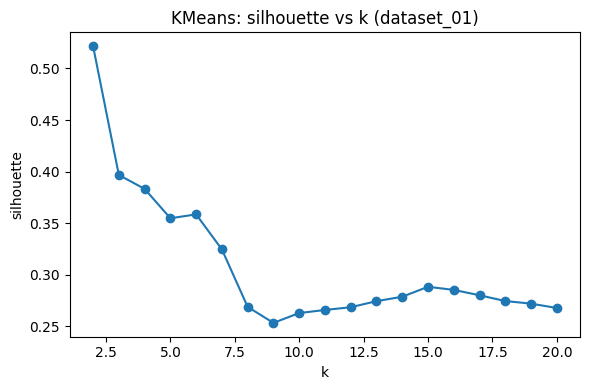

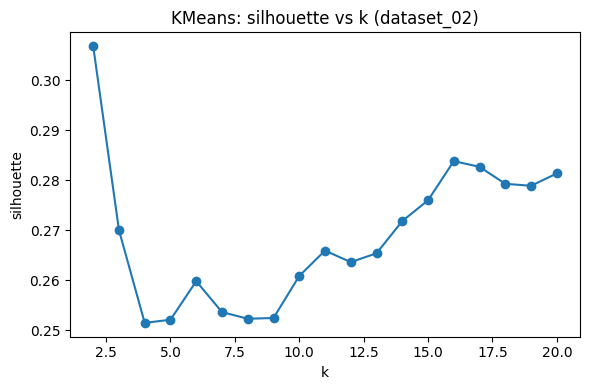

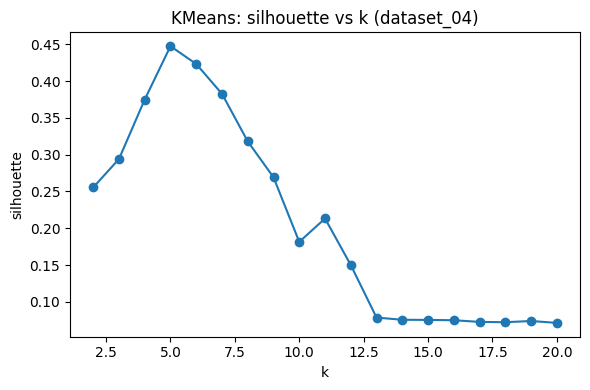

In [101]:
def save_kmeans_curve(dataset_key):
    df = kmeans_results[dataset_key].sort_values("k")
    plt.figure(figsize=(6, 4))
    plt.plot(df["k"], df["silhouette"], marker="o")
    plt.title(f"KMeans: silhouette vs k ({dataset_key})")
    plt.xlabel("k")
    plt.ylabel("silhouette")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"kmeans_silhouette_{dataset_key}.png", dpi=150)
    plt.show()

for ds in ["dataset_01", "dataset_02", "dataset_04"]:
    save_kmeans_curve(ds)

## 7. Итог по каждому датасету

Для **датасета dataset_01** наилучшее качество кластеризации показали методы
KMeans и AgglomerativeClustering с параметром k=2. Оба алгоритма дали
одинаковые значения silhouette, Davies–Bouldin и Calinski–Harabasz,
что указывает на чётко выраженную кластерную структуру шарообразного типа.

Основной сложностью при работе с данным датасетом была разная шкала
числовых признаков и наличие шумовых переменных, из-за чего без
масштабирования качество кластеризации существенно ухудшалось.
После применения StandardScaler структура данных стала хорошо
отделимой для distance-based методов.

Выбор KMeans в качестве итогового метода обусловлен его простотой,
высокой устойчивостью (подтверждённой ARI при нескольких запусках)
и полной эквивалентностью по качеству более сложному иерархическому
подходу в данном случае.

Для **датасета dataset_02** наилучшие результаты продемонстрировал алгоритм
DBSCAN с параметрами eps=1.0 и min_samples=20. Он показал существенно
более высокие значения silhouette и Davies–Bouldin по сравнению с KMeans,
а также корректно выделил небольшую долю шумовых объектов.

Данный датасет характеризуется нелинейной структурой кластеров,
наличием выбросов и фонового шума, что делает геометрические методы
типа KMeans менее подходящими. KMeans оказался чувствителен к выбросам
и формировал менее интерпретируемые кластеры.

DBSCAN оказался уместным выбором благодаря плотностной логике,
способности выявлять кластеры произвольной формы и явной обработке
шума, что делает его предпочтительным методом для данного датасета.

Для **датасета dataset_04** лучшие результаты показали методы KMeans и
AgglomerativeClustering с параметром k=5. После аккуратного
препроцессинга данных (обработка пропусков, кодирование категориальных
признаков и масштабирование) оба алгоритма продемонстрировали
одинаковое качество кластеризации по всем использованным метрикам.

Основной сложностью при работе с данным датасетом была высокая
размерность данных, наличие категориальных признаков и пропусков,
что требовало явного и согласованного препроцессинга перед применением
distance-based методов.

В качестве итогового метода был выбран KMeans как более простой и
масштабируемый алгоритм, не уступающий иерархическому подходу по
качеству кластеризации в условиях корректно подготовленных данных.